# 24RB1003 松澤颯斗

# Rademacher 複雑度の計算

### 課題1：仮説集合の作成（$m = 10,\ B \in \{1,3,5\}$）

In [15]:
import numpy as np
import matplotlib.pyplot as plt

- 制限された整数ベクトル集合  
  $\mathbb{Z}_{\leq B}^{m} = \{-B, -B+1, \cdots, B-1, B\}^{m}$  
  から，ランダムに16個サンプリングし，$W$ を構成する

- 線形仮説集合  
  $\mathcal{H}_{B,W} = \{ f_w(x) := \langle w, x \rangle \mid w \in W \}$  
  を定める

- 以上を繰り返し，各 $B$ に対し，様々な線形仮説集合を作る

In [16]:
# 各Bに対してWを構成
m = 10
for B in [1, 3, 5]:
    W = np.random.randint(-B, B + 1, size=(16, m)) # 16個の整数をサンプリング
    print(f"B={B}\n{W}\n")

B=1
[[ 0  0  0  0 -1  1  0  1  1  0]
 [-1 -1 -1 -1 -1  1  1  1 -1  1]
 [-1  1  0  0 -1  0 -1  0 -1  1]
 [ 1 -1  1  0 -1  1  1  0 -1  0]
 [-1  1  1 -1  1  1  1 -1  0 -1]
 [ 1  0  1  0  0  0  1  1 -1  1]
 [-1  1  0 -1  1  1 -1 -1  0 -1]
 [-1 -1 -1  1  0  0  0 -1  1 -1]
 [ 0  0  1  1 -1 -1 -1 -1  0 -1]
 [ 1  0  0  1  1  0  0  0  1  0]
 [ 0  1  1  1 -1  1 -1  1  0  1]
 [ 0  1 -1 -1  1 -1  1 -1 -1  1]
 [-1  1 -1  0  0  1  1 -1  1  0]
 [-1 -1  0 -1 -1  0  1 -1  0 -1]
 [ 1 -1 -1 -1 -1  1  1  1  1 -1]
 [ 0 -1 -1  1  0 -1  1 -1  1  1]]

B=3
[[-2  2  2 -1 -3  1  3 -3 -3 -2]
 [ 2  2 -2 -2 -3 -3 -3 -2  0 -1]
 [-3  0  1  1 -3  1 -2 -1 -3  1]
 [ 2  1  3  1  0  2 -2  3 -1 -3]
 [-2  2  1  2 -2 -2  2  0  0 -3]
 [ 1  1 -1 -1  0  0  2 -1  0  1]
 [ 3  0  1 -1  3 -2  0  0  3 -3]
 [-3 -3  1  3  2  3  0  0  3 -1]
 [-1 -3  0 -1 -3  2  3  0  3 -1]
 [ 2 -3 -2  3  3 -1  1  1 -3  3]
 [-3  0  0  2  0 -1 -1 -2  3  3]
 [ 3 -2 -2  3  2 -1  3  1 -3 -3]
 [ 2 -2  1 -3  1  3 -1 -1  0 -2]
 [ 1 -2  3  0 -1  3  3  3 -1  3]


In [17]:
# 各Bに対して様々な仮説集合を作る
hypothesis_sets = {1: [], 3: [], 5: []}

for B in [1, 3, 5]:
    for _ in range(100): # 100回繰り返して様々な仮説集合を作る
        W = np.random.randint(-B, B + 1, size=(16, m))
        H = [lambda x, w=w: np.dot(w, x) for w in W] # 仮説集合Hを定義
    
        hypothesis_sets[B].append(H)

### 課題2：Rademacher 複雑度関数の実装

In [ ]:
import itertools # itertools をインポートして，Rademacher 複雑度の計算に使用するためのシグマの組み合わせを生成

sigmas = list(itertools.product([-1, 1], repeat=m)) # シグマの組み合わせを生成 1024通り

# Rademacher 複雑度を計算するための関数
def rademacher_complexity(H):
    max_values = []
    for sigma in sigmas:
        max_value = max([h(sigma) / m for h in H]) 
        max_values.append(max_value)

    return np.mean(max_values)

In [19]:
# 各Bに対して様々な仮説集合のRademacher複雑度を計算する
complexities = {1: [], 3: [], 5: []}

for B in [1, 3, 5]:
    for H in hypothesis_sets[B]:
        complexity = rademacher_complexity(H)
        
        complexities[B].append(complexity)


In [20]:
# 各Bに対して，複雑度の平均値を計算して表示する
for B in [1, 3, 5]:
    avg_complexity = np.mean(complexities[B])
    print(f"B={B}, Average Rademacher Complexity: {avg_complexity:.4f}")

B=1, Average Rademacher Complexity: 0.4503
B=3, Average Rademacher Complexity: 1.0989
B=5, Average Rademacher Complexity: 1.7501


### 課題3：プロット

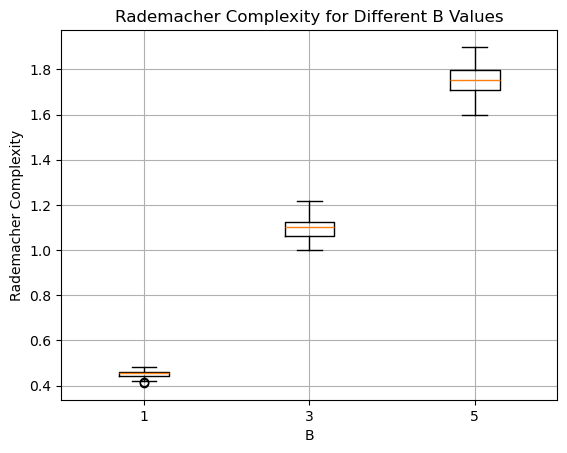

In [21]:
# 縦軸 Rademacher 複雑度，横軸 B のプロット
# 各Bに対して箱ひげ図で表現
plt.boxplot([complexities[B] for B in [1, 3, 5]], tick_labels=[1, 3, 5])
plt.xlabel('B')
plt.ylabel('Rademacher Complexity')
plt.title('Rademacher Complexity for Different B Values')
plt.grid()
plt.show()

# 考察

$B$の値が大きくなるにつれてRademacher複雑度も高まることが確認できた．これは，$B$の範囲が広がることで仮説集合が表現力を増し，ランダムなノイズに対しても都合よく適合しやすくなったためだと考えられる．表現力が高いモデルは真の関数を捉えやすい反面，訓練データのノイズにまで過敏に反応してしまう．その結果，汎化ギャップが拡大しやすくなるため，モデルの複雑さをむやみに上げることは必ずしも良い学習とは言えないと考えられる．したがって，未知のデータに対する真の誤差を抑えるためには，モデルの複雑さとデータ数のバランスを適切に取ることが重要である．

# AI使用について

Gemini Guided Learningを使用して，仮説集合のプログラム上での構成方法や，`itertools`を用いた全探索処理の実装について質問した．AI に直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．